# Bias-Variance Tradeoff and Learning Curves

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand bias and variance in machine learning
- Analyze bias-variance tradeoff through learning curves
- Identify and handle overfitting/underfitting
- Select optimal model complexity using validation sets

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 1, lesson 05 "Polynomial Regression" and Unit 2, lesson 01 "Cross-Validation" — degree sets model complexity, cross-validation measures what it costs.

**Used later in:** Course 04 — Unit 5, where model selection is exactly the search for the right point on this curve.

---

This notebook covers practical activities from **Course 04, Unit 2**:
- Analyzing bias-variance tradeoff through learning curves
- Identifying and handling overfitting/underfitting
- Selecting optimal model complexity using validation sets

---

## Introduction to Bias-Variance Tradeoff

**Bias**: Error from overly simplistic assumptions (underfitting)
**Variance**: Error from sensitivity to small fluctuations (overfitting)
**Tradeoff**: Finding the right balance between model complexity and generalization


## 🌍 A real case: when more data beat a better algorithm

In 2001 Michele Banko and Eric Brill (Microsoft Research) trained four different learners on the same
language task — picking the right word from a confusable set — using training corpora that grew from
one million words to **one billion**. Their learning curves never flattened. More striking, the
*ranking of the algorithms changed with data size*: a learner that was clearly worst on a million
words overtook the others once it had a billion ("Scaling to Very Very Large Corpora for Natural
Language Disambiguation", ACL 2001).

**❗ Why this lesson exists.** Two teams can be stuck at the same error and need opposite things.
Read the numbers this notebook prints:

| Model | Train MSE | Val MSE | Gap |
|---|---|---|---|
| Degree 1 | 1936.53 | 2161.84 | 225.31 |
| Degree 4 | 206.83 | 247.24 | 40.41 |
| Degree 15 | 292.33 | 42429.78 | **42137.44** |

Degree 1 is bad on data it has *already seen* — more data cannot help a model that cannot represent
the curve. Degree 15 is nearly perfect on training data and useless on validation — more data is the
one thing that would help it. Same dataset, opposite prescriptions, and a single accuracy number
cannot tell them apart. The learning curve can.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `load("montgomery_911_calls", prefer="sample")` — the real dispatch log you met in Unit 1. There is
  no file path to get wrong: the loader finds the data from any working directory, downloads it on
  Google Colab, and prints which copy it used. We keep the **calendar year 2019** and count how many
  calls fall in each half-hour slot of the day — 48 points, the shape of an average day.
- `prefer="sample"` means everyone reads the same 25,000-row extract that ships with the repository
  (1 call in every 27), so every number below is identical on every machine. Those counts are
  therefore about **1/27 of the county's real call volume**; the *shape* of the day, which is all this
  lesson uses, is what survives the sampling.

**Outputs:** What you'll see when you run the cells

- Learning curves for three model complexities, a computed underfit/good-fit/overfit diagnosis
  for each, and the degree that minimizes validation error.

---

In [1]:
# CELL: Import the tools for this lesson.
# WHY: learning_curve() does the heavy lifting - it retrains a model on
# growing slices of data so we can watch bias and variance appear.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")


Data loader ready - no file paths needed, and this works on Colab too.


In [3]:
# Build the dataset from a REAL emergency dispatch log (Montgomery County, PA).
# WHY real: on invented data you can print the exact noise floor and grade models against
# it. Real data gives you no such number - you have to diagnose bias and variance from the
# learning curves alone, which is the skill this notebook is actually teaching.
# WHY load(...) and not a file path: it finds the log from ANY working directory - your
# laptop, JupyterLab opened at the repository root, or Colab where there is no repository -
# and prints which copy it used. WHY prefer="sample": the 25,000-row extract ships inside
# the repository (1 call in every 27, evenly spread), so everyone in the class reads the
# same numbers whether or not they downloaded the 663,522-row original.
calls = load("montgomery_911_calls", prefer="sample", usecols=["timeStamp"])
stamps = pd.to_datetime(calls["timeStamp"], errors="coerce").dropna()

# Keep one whole calendar year - 2019 - and count the calls that fall in each half-hour
# slot of the day.
# WHY a whole year: it balances weekdays against weekends and winter against summer, so the
#     48 points describe "a day in this county" rather than one unusual fortnight.
# WHY 2019: the last complete year in the log, and the last one before the pandemic changed
#     what people call 911 about.
# WHY count rather than average over a handful of days: the bundled sample keeps 1 call in
#     27, so a 30-day window would leave well under one call per slot per day and the shape
#     of the day would vanish into rounding.
year = stamps[stamps.dt.year == 2019]
slot = (year.dt.hour * 60 + year.dt.minute) // 30              # 0..47
counts = slot.value_counts().reindex(range(48), fill_value=0).sort_index()

X = (counts.index.to_numpy(dtype=float) * 0.5).reshape(-1, 1)  # hour of day, 0.0 .. 23.5
y = counts.to_numpy(dtype=float)                               # calls logged in that half hour

print(f"Samples: {X.shape[0]} half-hour slots   Period: {year.dt.date.min()} to {year.dt.date.max()}")
print(f"Calls counted: {len(year):,} (every 2019 call in the copy loaded above)")
print(f"Feature range: hour {X.min():.1f} to {X.max():.1f}")
print(f"Target range: [{y.min():.0f}, {y.max():.0f}] calls per slot, variance {y.var():.2f}")
print("There is no known noise floor here - the day-to-day randomness in a county's")
print("emergencies is whatever it is. We will have to infer it from the curves.")


montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
Samples: 48 half-hour slots   Period: 2019-01-01 to 2019-12-31
Calls counted: 5,618 (every 2019 call in the copy loaded above)
Feature range: hour 0.0 to 23.5
Target range: [30, 206] calls per slot, variance 2697.58
There is no known noise floor here - the day-to-day randomness in a county's
emergencies is whatever it is. We will have to infer it from the curves.


## Part 1: Learning Curves - Analyzing Model Performance

**A quick note on `Pipeline`** (new sklearn object): `Pipeline([('poly', PolynomialFeatures(...)), ('linear', LinearRegression())])` chains a transform step and a model into ONE object that behaves like a single model (`fit`/`predict`). We need it because `learning_curve` refits the model many times on different folds - the pipeline guarantees the polynomial features are recomputed inside every fold from that fold's training data only (no leakage between folds).


Degree 1:
  Final train MSE: 1936.5315
  Final val MSE:   2161.8407
Degree 4:
  Final train MSE: 206.8322
  Final val MSE:   247.2399
Degree 15:
  Final train MSE: 292.3317
  Final val MSE:   42429.7761

Baseline - predict the overall average every time: MSE 2697.582


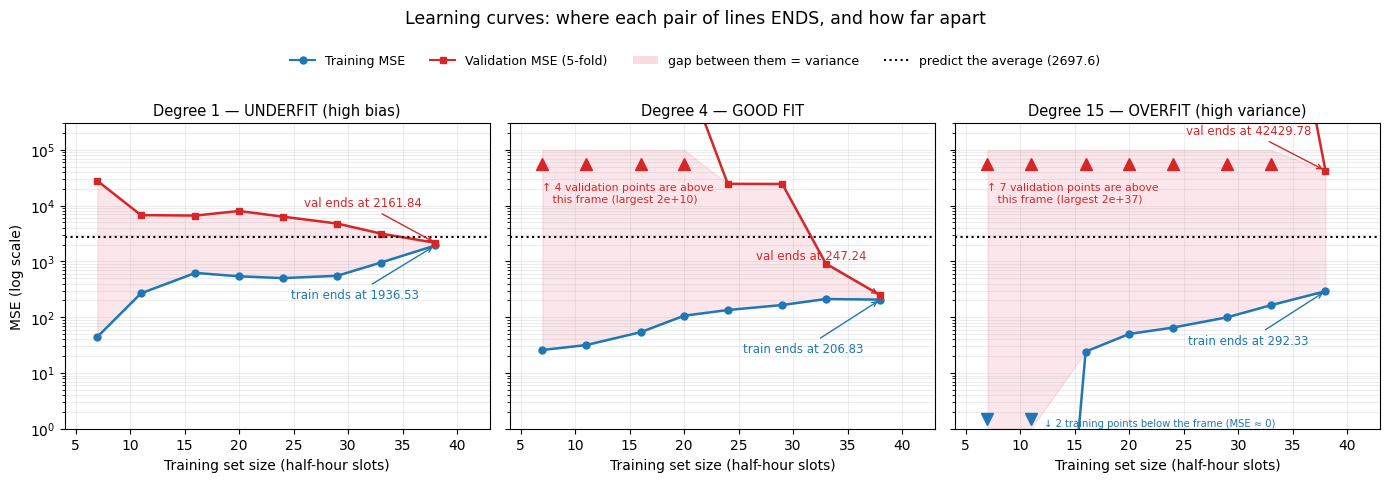

In [4]:
# Create learning curves for different model complexities
#
# NOTE on cross-validation: our X values are SORTED (hour 0 -> 23.5) and
# learning_curve does not shuffle by default. Unshuffled folds would hold out
# a contiguous chunk of the x-range, forcing the model to EXTRAPOLATE far
# outside its training range - that measures extrapolation, not generalization.
# A shuffled KFold gives every fold a representative slice of the x-range.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

degrees = [1, 4, 15]
models = {}

for degree in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 8),
        scoring='neg_mean_squared_error'
    )

    models[degree] = {
        'train_sizes': train_sizes,
        'train_mean': -train_scores.mean(axis=1), 'train_std': train_scores.std(axis=1),
        'val_mean': -val_scores.mean(axis=1), 'val_std': val_scores.std(axis=1)
    }

    print(f"Degree {degree}:")
    print(f"  Final train MSE: {models[degree]['train_mean'][-1]:.4f}")
    print(f"  Final val MSE:   {models[degree]['val_mean'][-1]:.4f}")

# A yardstick to judge every MSE against: what you would score by ignoring the
# hour of day entirely and predicting the overall average call volume every time.
BASELINE_MSE = y.var()
print(f"\nBaseline - predict the overall average every time: MSE {BASELINE_MSE:.3f}")

# ---------------------------------------------------------------------------
# PLOT: one panel per complexity, TRAINING vs VALIDATION error as data grows.
# WHY log y: on tiny training sets a degree-15 polynomial swings wildly between
# the few points it has seen, so its validation MSE reaches ~1e37. A linear axis
# would flatten everything else to a single line at the bottom.
# WHY the frame is capped at [1, 100000]: inside that window the numbers that
# decide the lesson (292 vs 247 vs 2162 vs 2698 vs 42430) are far enough apart
# to read. Points outside the window are NOT hidden - they are drawn as
# triangles on the frame edge with their true magnitude printed, so nothing is
# silently clipped.
# ---------------------------------------------------------------------------
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

TOP, BOT = 1e5, 1e0
verdict = {1: "UNDERFIT (high bias)", 4: "GOOD FIT", 15: "OVERFIT (high variance)"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)
for ax, degree in zip(axes, degrees):
    m = models[degree]
    ts, tr, va = m['train_sizes'], m['train_mean'], m['val_mean']

    # Shade the gap between the two lines - that gap IS the variance.
    ax.fill_between(ts, np.clip(tr, BOT, TOP), np.clip(va, BOT, TOP),
                    color='crimson', alpha=0.10)
    ax.plot(ts, tr, '-', color='#1f77b4', lw=1.8)
    ax.plot(ts[tr >= BOT], tr[tr >= BOT], 'o', color='#1f77b4', ms=5)
    ax.plot(ts, va, '-', color='#d62728', lw=1.8)
    ax.plot(ts[va <= TOP], va[va <= TOP], 's', color='#d62728', ms=5)

    # Honest markers for anything that falls outside the frame.
    off = va > TOP
    if off.any():
        ax.plot(ts[off], np.full(off.sum(), TOP * 0.55), '^', color='#d62728', ms=9)
        ax.text(ts[0], TOP * 0.26,
                f"↑ {off.sum()} validation points are above\n   this frame (largest {va.max():.0e})",
                fontsize=7.8, color='#d62728', va='top')
    low = tr < BOT
    if low.any():
        ax.plot(ts[low], np.full(low.sum(), BOT * 1.5), 'v', color='#1f77b4', ms=9)
        ax.text(ts[low][-1] + 1.2, BOT * 1.03,
                f"↓ {low.sum()} training points below the frame (MSE ≈ 0)",
                fontsize=7.2, color='#1f77b4', va='bottom', ha='left')

    ax.axhline(BASELINE_MSE, ls=':', color='k', lw=1.5)
    ax.set_yscale('log')
    ax.set_ylim(BOT, TOP * 3)
    ax.set_xlim(4, 43)
    ax.set_xlabel('Training set size (half-hour slots)')
    ax.grid(alpha=0.22, which='both')
    ax.set_title(f'Degree {degree} — {verdict[degree]}', fontsize=10.5)
    ax.annotate(f'val ends at {va[-1]:.2f}', xy=(ts[-1], va[-1]), xytext=(-10, 26),
                textcoords='offset points', ha='right', fontsize=8.5, color='#d62728',
                arrowprops=dict(arrowstyle='->', color='#d62728', lw=1))
    ax.annotate(f'train ends at {tr[-1]:.2f}', xy=(ts[-1], tr[-1]), xytext=(-12, -38),
                textcoords='offset points', ha='right', fontsize=8.5, color='#1f77b4',
                arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1))

axes[0].set_ylabel('MSE (log scale)')
handles = [
    Line2D([], [], color='#1f77b4', marker='o', ms=5, label='Training MSE'),
    Line2D([], [], color='#d62728', marker='s', ms=5, label='Validation MSE (5-fold)'),
    Patch(facecolor='crimson', alpha=0.15, label='gap between them = variance'),
    Line2D([], [], color='k', ls=':', label=f'predict the average ({BASELINE_MSE:.1f})'),
]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, 0.925))
plt.suptitle('Learning curves: where each pair of lines ENDS, and how far apart', fontsize=12.5, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


### What to see in the learning curves above

Read each panel by asking **where do the two lines end, and how far apart?**

- **Degree 1** — the lines *meet*, at MSE **1936.53** (train) and **2161.84** (validation). No gap left
  to close: more data will not help, because the model has already learned everything a straight line
  can learn. But look where they meet — just *below* the dotted line at **2697.6**, the score you get
  by ignoring the hour of day and predicting the average. A straight line through the day barely
  beats no model at all. **That is bias.**
- **Degree 4** — the lines converge to **206.83** and **247.24**, a gap of 40.41, and both land far
  below the dotted baseline. Small gap, low error: the pink band has almost closed by the right edge.
- **Degree 15** — the widest pink band in the figure, and it never closes. Training error ends at
  **292.33**, better than degree 4; validation error ends at **42429.78**, which is *above* the dotted
  line. With all the data we have, this model is worse than predicting the average. **That is variance.**

The triangles on the top edge are not decoration: degree 1's validation curve stays inside the frame,
but degree 4 has 4 validation points and degree 15 has 7 validation points that lie *above* it — the
largest at **2e+37**. They are drawn on the edge with their magnitude printed rather than quietly
cropped. A flexible model handed too little data does not degrade gracefully — it detonates.

## Part 2: Identifying Overfitting and Underfitting

We now classify each model as **underfitting**, **good fit**, or **overfitting**.

The labels below are **computed from the measured errors** with explicit
thresholds - not written by hand - so the printed interpretation always
matches the numbers.

One thing changes when the data is real: we no longer know the irreducible error, because
nobody generated these call volumes from a formula. So we use the **best validation MSE any
of our candidate models achieved** as a practical stand-in for "as good as it gets on this
data". Be aware of what that costs us: the best model is graded against itself, so it can
never be labelled underfitting. That is an honest limitation of working without ground
truth, not a trick - and it is the normal situation outside a textbook.

In [5]:
# Bias-variance diagnosis - labels are COMPUTED from the measured MSE values,
# so the printed interpretation can never disagree with the numbers.

# Best validation MSE across our candidates: our empirical stand-in for the
# irreducible error, since real data comes with no stated noise level.
REFERENCE_MSE = min(models[d]['val_mean'][-1] for d in degrees)

def diagnose(train_mse, val_mse):
    """Classify fit quality from final train/validation MSE.

    Rules (checked in order):
      1. OVERFITTING:  val > 2 x train AND gap > reference
                       (validation error far above training error)
      2. UNDERFITTING: val > 3 x reference
                       (even validation error is far above the best we achieved)
      3. GOOD FIT:     otherwise (both errors low and close together)
    """
    gap = val_mse - train_mse
    if val_mse > 2 * train_mse and gap > REFERENCE_MSE:
        return "OVERFITTING (high variance)"
    if val_mse > 3 * REFERENCE_MSE:
        return "UNDERFITTING (high bias)"
    return "GOOD FIT (balanced bias-variance)"

print("=" * 60)
print("Bias-Variance Analysis (labels computed from the numbers)")
print("=" * 60)
print(f"Reference MSE (best validation error achieved): {REFERENCE_MSE:.3f}")
print(f"For scale, predicting the overall average every time scores MSE {y.var():.3f}")

for degree in degrees:
    train_mse = models[degree]['train_mean'][-1]
    val_mse = models[degree]['val_mean'][-1]
    gap = val_mse - train_mse
    label = diagnose(train_mse, val_mse)
    print(f"\nDegree {degree}:")
    print(f"  Train MSE: {train_mse:.4f}")
    print(f"  Val MSE:   {val_mse:.4f}")
    print(f"  Gap:       {gap:.4f}")
    print(f"  Diagnosis: {label}")

# Pick the optimal complexity by validation error
best_degree = min(models, key=lambda d: models[d]['val_mean'][-1])
best_label = diagnose(models[best_degree]['train_mean'][-1],
                      models[best_degree]['val_mean'][-1])
print("\n" + "=" * 60)
print(f"Optimal model complexity by validation MSE: degree {best_degree}")
print(f"Its computed diagnosis: {best_label}")
print("=" * 60)

Bias-Variance Analysis (labels computed from the numbers)
Reference MSE (best validation error achieved): 247.240
For scale, predicting the overall average every time scores MSE 2697.582

Degree 1:
  Train MSE: 1936.5315
  Val MSE:   2161.8407
  Gap:       225.3092
  Diagnosis: UNDERFITTING (high bias)

Degree 4:
  Train MSE: 206.8322
  Val MSE:   247.2399
  Gap:       40.4077
  Diagnosis: GOOD FIT (balanced bias-variance)

Degree 15:
  Train MSE: 292.3317
  Val MSE:   42429.7761
  Gap:       42137.4444
  Diagnosis: OVERFITTING (high variance)

Optimal model complexity by validation MSE: degree 4
Its computed diagnosis: GOOD FIT (balanced bias-variance)


## Part 3: The tradeoff itself — sweeping complexity

The learning curves fixed the complexity and grew the data. Now we do the opposite: keep all 48
half-hour slots and walk the polynomial degree from 1 to 15, scoring every degree with the **same
cross-validator**, so these numbers sit on the same scale as the ones above.

Complexity sweep - identical CV to the learning curves above
 degree   train MSE     val MSE        gap   notes
      1   1936.5315   2161.8407   225.3092   drawn below
      2    666.7907    767.3140   100.5234   drawn below
      3    320.1350    434.0198   113.8848   
      4    206.8322    247.2399    40.4077   *** LOWEST VALIDATION ERROR ***; drawn below
      5    191.4194    285.7917    94.3723   
      6    187.1049    297.3608   110.2559   
      7    138.6978    333.8894   195.1916   
      8    125.6040    255.4763   129.8724   drawn below
      9    109.4283    817.2062   707.7779   
     10    104.8044    916.0681   811.2637   
     11    100.1309    306.8453   206.7144   
     12    119.8885    427.8636   307.9751   
     13    139.1765    442.2620   303.0855   
     14    187.8071   9387.2353  9199.4282   worse than predicting the average
     15    292.3317  42429.7761 42137.4444   worse than predicting the average; drawn below
------------------------------------------

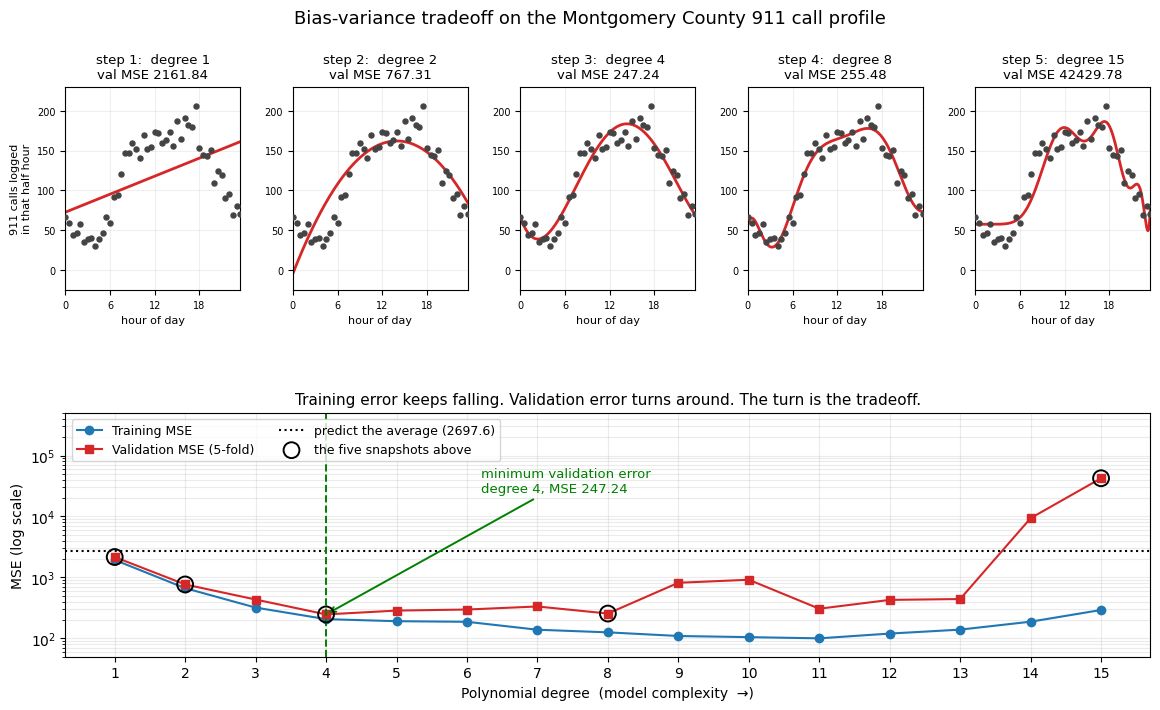

In [6]:
# ---------------------------------------------------------------------------
# THE BIAS-VARIANCE TRADEOFF, AS A STORYBOARD.
#
# The learning curves above answered "does more DATA help?" for three fixed
# complexities. This cell answers the other question: "which COMPLEXITY?" - by
# sweeping degree 1..15 and, for five of them, drawing the actual fitted curve.
#
# WHY the numbers here match the ones above exactly: we score every degree with
# the SAME learning_curve() call and the SAME cv object, asking only for the
# largest training size. Degrees 1, 4 and 15 therefore reproduce the figures
# printed earlier to the last decimal - the two figures can never disagree.
# ---------------------------------------------------------------------------
sweep_degrees = list(range(1, 16))
sweep = {}
for degree in sweep_degrees:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree)),
                     ('linear', LinearRegression())])
    _, tr_s, va_s = learning_curve(pipe, X, y, cv=cv,
                                   train_sizes=np.array([1.0]),
                                   scoring='neg_mean_squared_error')
    sweep[degree] = (-tr_s.mean(axis=1)[-1], -va_s.mean(axis=1)[-1])

best_sweep = min(sweep, key=lambda d: sweep[d][1])

# Printed step table - the storyboard in numbers, so you can check the picture.
print("=" * 64)
print("Complexity sweep - identical CV to the learning curves above")
print("=" * 64)
print(f"{'degree':>7} {'train MSE':>11} {'val MSE':>11} {'gap':>10}   notes")
snapshot_degrees = [1, 2, 4, 8, 15]
for degree in sweep_degrees:
    tr_d, va_d = sweep[degree]
    notes = []
    if degree == best_sweep:
        notes.append("*** LOWEST VALIDATION ERROR ***")
    if va_d > BASELINE_MSE:
        notes.append("worse than predicting the average")
    if degree in snapshot_degrees:
        notes.append("drawn below")
    print(f"{degree:>7} {tr_d:>11.4f} {va_d:>11.4f} {va_d - tr_d:>10.4f}   {'; '.join(notes)}")
print("-" * 64)
print(f"Lowest validation MSE: degree {best_sweep} ({sweep[best_sweep][1]:.4f})")
print(f"Cell above chose:      degree {best_degree} ({models[best_degree]['val_mean'][-1]:.4f})")
print("The two agree." if best_sweep == best_degree else "The two DISAGREE - investigate.")

# --- Draw: top row = five snapshots of the fitted curve, bottom = the sweep ---
grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)

fig = plt.figure(figsize=(14, 7.4))
gs = fig.add_gridspec(2, 5, height_ratios=[1, 1.2], hspace=0.55, wspace=0.30)

for k, degree in enumerate(snapshot_degrees):
    ax = fig.add_subplot(gs[0, k])
    fitted = Pipeline([('poly', PolynomialFeatures(degree=degree)),
                       ('linear', LinearRegression())]).fit(X, y)
    ax.scatter(X, y, s=13, color='#444', zorder=3, label='real data')
    ax.plot(grid, fitted.predict(grid), color='#d62728', lw=2)
    ax.set_ylim(-25, 230)
    ax.set_xlim(0, 23.5)
    ax.set_xticks([0, 6, 12, 18])
    ax.set_title(f'step {k + 1}:  degree {degree}\nval MSE {sweep[degree][1]:.2f}', fontsize=9.5)
    ax.set_xlabel('hour of day', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)
    if k == 0:
        ax.set_ylabel('911 calls logged\nin that half hour', fontsize=8)

ax = fig.add_subplot(gs[1, :])
tr_line = [sweep[d][0] for d in sweep_degrees]
va_line = [sweep[d][1] for d in sweep_degrees]
ax.plot(sweep_degrees, tr_line, 'o-', color='#1f77b4', label='Training MSE')
ax.plot(sweep_degrees, va_line, 's-', color='#d62728', label='Validation MSE (5-fold)')
ax.axhline(BASELINE_MSE, ls=':', color='k', lw=1.5,
           label=f'predict the average ({BASELINE_MSE:.1f})')
ax.axvline(best_sweep, color='green', ls='--', lw=1.4)
ax.scatter(snapshot_degrees, [sweep[d][1] for d in snapshot_degrees],
           s=130, facecolors='none', edgecolors='k', lw=1.4, zorder=5,
           label='the five snapshots above')
ax.annotate(f'minimum validation error\ndegree {best_sweep}, MSE {sweep[best_sweep][1]:.2f}',
            xy=(best_sweep, sweep[best_sweep][1]), xytext=(6.2, 25000),
            fontsize=9.5, color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=1.4))
ax.set_yscale('log')
ax.set_ylim(50, 5e5)           # headroom so the legend and the green note
                               # sit inside the frame, clear of the title
ax.set_xticks(sweep_degrees)
ax.set_xlabel('Polynomial degree  (model complexity  →)')
ax.set_ylabel('MSE (log scale)')
ax.grid(alpha=0.25, which='both')
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.set_title('Training error keeps falling. Validation error turns around. '
             'The turn is the tradeoff.', fontsize=11)
plt.suptitle('Bias-variance tradeoff on the Montgomery County 911 call profile',
             fontsize=13, y=0.985)
plt.show()


### What to see in the storyboard above

**Top row — five snapshots of the same day, five complexities.** Follow the red curve left to right:

1. **Degree 1** is a straight line sloping gently upward. The real profile is a *hill* — quietest in
   the 4 a.m. slot (**30** calls in the whole of 2019), peaking at 5:30 p.m. (**206**) — and a straight
   line cannot bend. It runs above the data all morning and below it all afternoon. Underfitting is
   visible to the naked eye.
2. **Degree 2** bends and catches the hill — but a parabola is symmetric, so to reach the
   late-afternoon peak it has to dive at both ends. Look at midnight on the left edge: it predicts
   **−4 calls**, a negative count, where **67** were actually logged.
3. **Degree 4** tracks the real shape: the overnight trough, the morning rise, the late-afternoon peak.
4. **Degree 8** grows an extra bend in the small hours and a flatter, wider peak — it has started
   chasing individual points rather than the shape of the day.
5. **Degree 15** wiggles through the cloud, bending toward single points.

Now the uncomfortable part: **to the eye, degree 15 is the closest fit of the five** — and its
validation MSE, **42429.78**, is the *worst* of the five, and worse than predicting the average
(**2697.6**). Overfitting is not visible on the data the model was fitted to. That is precisely why it
needs a held-out measurement to catch it.

**Bottom panel — the tradeoff.** The blue training curve slides down from 1936.53 to about 100 by
degree 11 and then drifts back up — not because extra capacity fits the training rows worse in
principle, but because fitting a degree-15 polynomial to 38 points is numerically unstable. What it
never does is turn *where it matters*: nothing in the training error tells you to stop at 4. The red
validation curve does, falling steeply to its **minimum at degree 4 (247.24)** — marked by the green
dashed line — then climbing. The five circled red points are the five snapshots above.

Note also the *shape* of the red curve past degree 8: it lurches (817.21, 916.07, 306.85, 427.86,
442.26, 9387.24, 42429.78) instead of rising smoothly. That jaggedness is variance showing itself
directly — with 38 training points, a degree-12 fit is so unstable that changing which points it sees
moves its held-out error by an order of magnitude. Do not read those wiggles as "degree 11 is better
than degree 10"; read them as "everything out here is unreliable".

## 💬 Discuss

1. **You have budget for exactly one of:** (a) collecting three more months of dispatch data, or
   (b) trying a different family of model. Which do you buy for the degree-1 model, which for the
   degree-15 model, and what in the table above forces each choice?

2. **Predicting the overall average scores MSE 2697.58. Degree 1 scores 2161.84.** Better — but not by
   much, for all the work. At what point is a model "not worth having" compared with a constant?
   Commit to a rule and defend it against someone who says any improvement is an improvement.

3. **This dataset is 48 half-hour slots.** The degree-15 validation error on the smallest training
   sets runs off the top of a log-scaled plot. Is that a fact about degree-15 polynomials, or a fact
   about having 48 rows? Design the check that would tell the two apart.

## ⚠️ Where this breaks

- **The diagnosis is only as fair as the validation set.** These 48 slots pool the whole of 2019 in a
  single county, and they are counted from the bundled 1-in-27 sample, so each one is roughly a
  twenty-seventh of the calls that really came in. A model labelled "good fit" on 2019 can be badly
  biased on 2020, when the pandemic changed what people called 911 about, and the learning curve will
  not say so.
- **Learning curves are expensive.** They refit the model at every training size, for every fold. With
  a model that takes hours to train, a single train-versus-validation gap at full data size answers
  the "more data or better model?" question at a fraction of the cost.
- **The assumption that must hold:** the new data would come from the same process as the old. If you
  can only obtain *different* data — another county, another year — the curve's promise that more data
  helps does not transfer.
- **What the curve cannot tell you:** whether the *features* are right. A curve that is flat and high
  for every model size means your columns do not carry the signal. No amount of extra rows or extra
  model capacity fixes a measurement you did not take.


## Summary

### Key Concepts:
1. **Bias**: Model too simple, cannot capture patterns (underfitting)
2. **Variance**: Model too complex, memorizes noise (overfitting)
3. **Learning Curves**: Show train/validation performance vs training set size
4. **Optimal Complexity**: Balance where validation error is minimized

### How to Use:
- **Large gap between train/val**: Overfitting → reduce complexity
- **Both train/val high**: Underfitting → increase complexity
- **Both train/val similar and low**: Good model
- **No known noise floor**: on real data, compare candidates against each other and against
  the trivial "predict the mean" baseline, and watch the shape of the curves — a validation
  curve still falling at the right-hand edge means *more data would help*; one that has
  flattened far above the training curve means *a different model would help*.

**Reference:** Course 04, Unit 2: "Analyzing bias-variance tradeoff through learning curves" and "Identifying and handling overfitting/underfitting"


## 🔭 State of the field (2026)

*Field context, not examinable material — the examinable content of this lesson is everything above this box.*

Learning curves and the bias–variance decomposition are still how you answer the question this
notebook asks — "would more data help, or do I need a different model?" — and no 2026 technique
replaces them. What changed is what a finished model is expected to *output*: handing over a single
number with no statement of uncertainty is no longer normal practice. Split-conformal prediction wraps
an already-fitted model in an interval (or, for a classifier, a set) carrying a distribution-free
coverage guarantee, using one held-out calibration split and about twenty lines of code (Angelopoulos
& Bates, 2021, arXiv:2107.07511; Angelopoulos, Barber & Bates, 2024, arXiv:2411.11824). The two are
complementary, not competing: the learning curve tells you *where* the error is coming from, the
conformal interval tells you *how wide* it is on the next unseen row. And conformal is no escape from
the honest limitation named in "Where this breaks" above — its guarantee assumes the new data is
exchangeable with the calibration data, so a model calibrated on this one holiday window says nothing
reliable about July. Learn the curves first; add the interval when you hand the model to someone who
will act on it.

## 📚 References

1. Geman, S., Bienenstock, E., & Doursat, R. (1992). *Neural Networks and the Bias/Variance Dilemma*. Neural Computation, 4(1), 1–58.
2. Belkin, M., Hsu, D., Ma, S., & Mandal, S. (2019). *Reconciling Modern Machine Learning Practice and the Bias-Variance Trade-off*. PNAS, 116(32). <https://arxiv.org/abs/1812.11118>
3. Viering, T., & Loog, M. (2023). *The Shape of Learning Curves: A Review*. IEEE Transactions on Pattern Analysis and Machine Intelligence, 45(6). <https://arxiv.org/abs/2103.10948>
4. Angelopoulos, A. N., & Bates, S. (2021). *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification*. <https://arxiv.org/abs/2107.07511>
5. Angelopoulos, A. N., Barber, R. F., & Bates, S. (2024). *Theoretical Foundations of Conformal Prediction*. <https://arxiv.org/abs/2411.11824>
